In [56]:
# ==========================================================
# Daily Revenue Forecast using Prophet
# Forecast Horizon: Next 90 Days
# ==========================================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# ==========================================================
# 1. Load Dataset
# ==========================================================

data = pd.read_csv(
    r"D:\Data Analyst\EXCEL\supplychain\cleaned\final_cleaned.csv"
)

df = data.copy()

# ==========================================================
# 2. Data Preparation
# ==========================================================

# Convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Train on historical data only
df = df[df['order_date'] < pd.Timestamp('2026-04-01')]

# ==========================================================
# 3. Daily Revenue Aggregation
# ==========================================================

daily_sales = (
    df.groupby('order_date')['net_amount']
      .sum()
      .reset_index()
)

# Prophet column names
daily_sales.columns = ['ds', 'y']

# Sort by date
daily_sales = daily_sales.sort_values('ds').reset_index(drop=True)

# ==========================================================
# 4. Build Prophet Model
# ==========================================================

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)

# Fit Model
model.fit(daily_sales)

# ==========================================================
# 5. Forecast Next 90 Days
# ==========================================================

future = model.make_future_dataframe(
    periods=90,
    freq='D'
)

forecast = model.predict(future)

# ==========================================================
# 6. Keep Important Columns
# ==========================================================

forecast_result = forecast[
    [
        'ds',
        'yhat',
        'yhat_lower',
        'yhat_upper',
        'trend'
    ]
]

print("\nForecast")
print(forecast_result.tail(10))

# ==========================================================
# 7. Combine Actual + Forecast
# ==========================================================

final_result = daily_sales.merge(
    forecast_result,
    on='ds',
    how='outer'
)

# ==========================================================
# 8. Export Forecast
# ==========================================================

final_result.to_csv(
    r"D:\Data Analyst\EXCEL\supplychain\cleaned\forcast\daily_revenue_forecast.csv",
    index=False
)

print("\nForecast exported successfully.")


21:28:22 - cmdstanpy - INFO - Chain [1] start processing
21:28:22 - cmdstanpy - INFO - Chain [1] done processing



Forecast
            ds          yhat    yhat_lower    yhat_upper         trend
444 2026-06-20  7.705712e+07  6.168454e+07  9.231097e+07  8.227741e+07
445 2026-06-21  7.547677e+07  6.077974e+07  9.097997e+07  8.223416e+07
446 2026-06-22  7.522349e+07  6.136288e+07  8.916630e+07  8.219090e+07
447 2026-06-23  7.724495e+07  6.254471e+07  9.190757e+07  8.214765e+07
448 2026-06-24  7.670127e+07  6.210111e+07  9.151154e+07  8.210440e+07
449 2026-06-25  7.686065e+07  6.167672e+07  9.197936e+07  8.206115e+07
450 2026-06-26  7.640873e+07  6.206759e+07  9.234007e+07  8.201790e+07
451 2026-06-27  7.728741e+07  6.171328e+07  9.175324e+07  8.197465e+07
452 2026-06-28  7.576386e+07  6.143739e+07  9.089799e+07  8.193140e+07
453 2026-06-29  7.556201e+07  6.044938e+07  9.009414e+07  8.188815e+07

Forecast exported successfully.


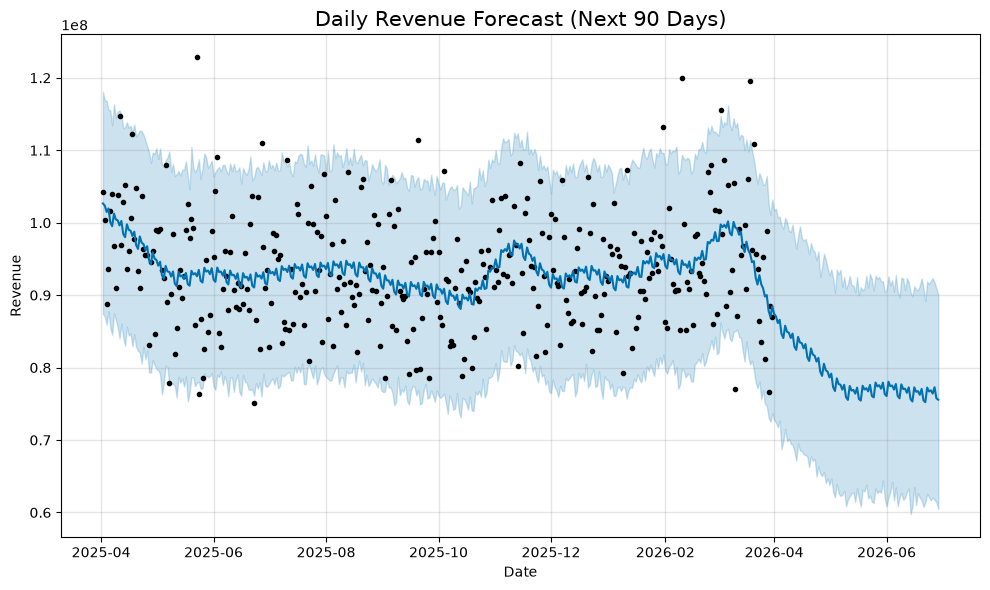

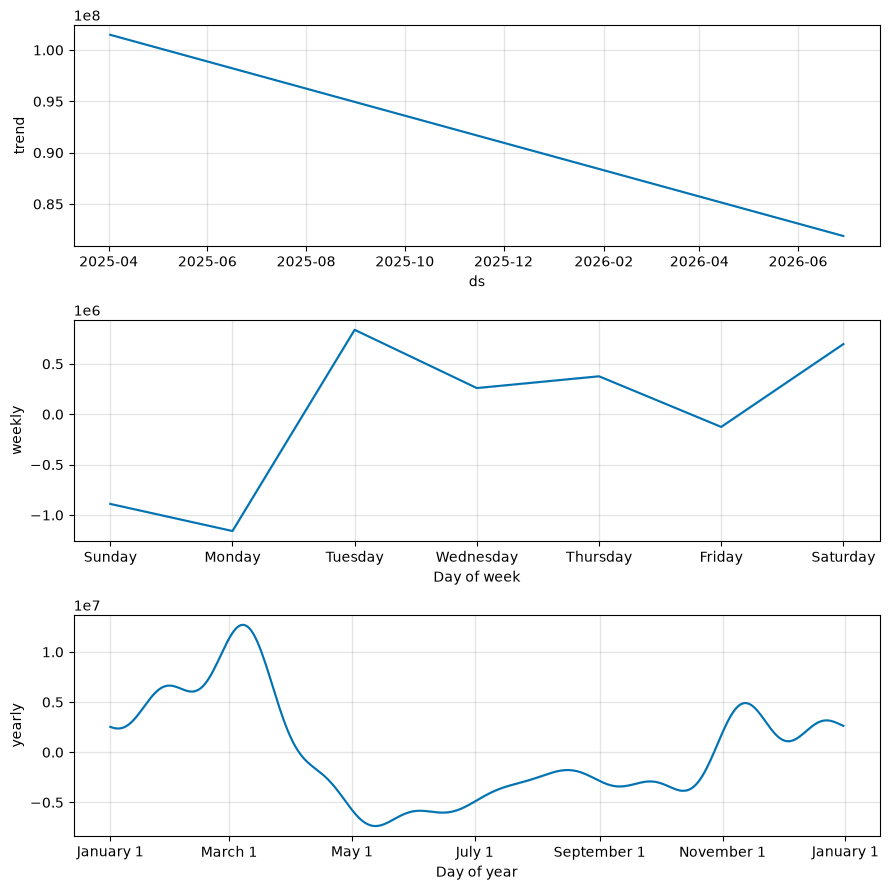

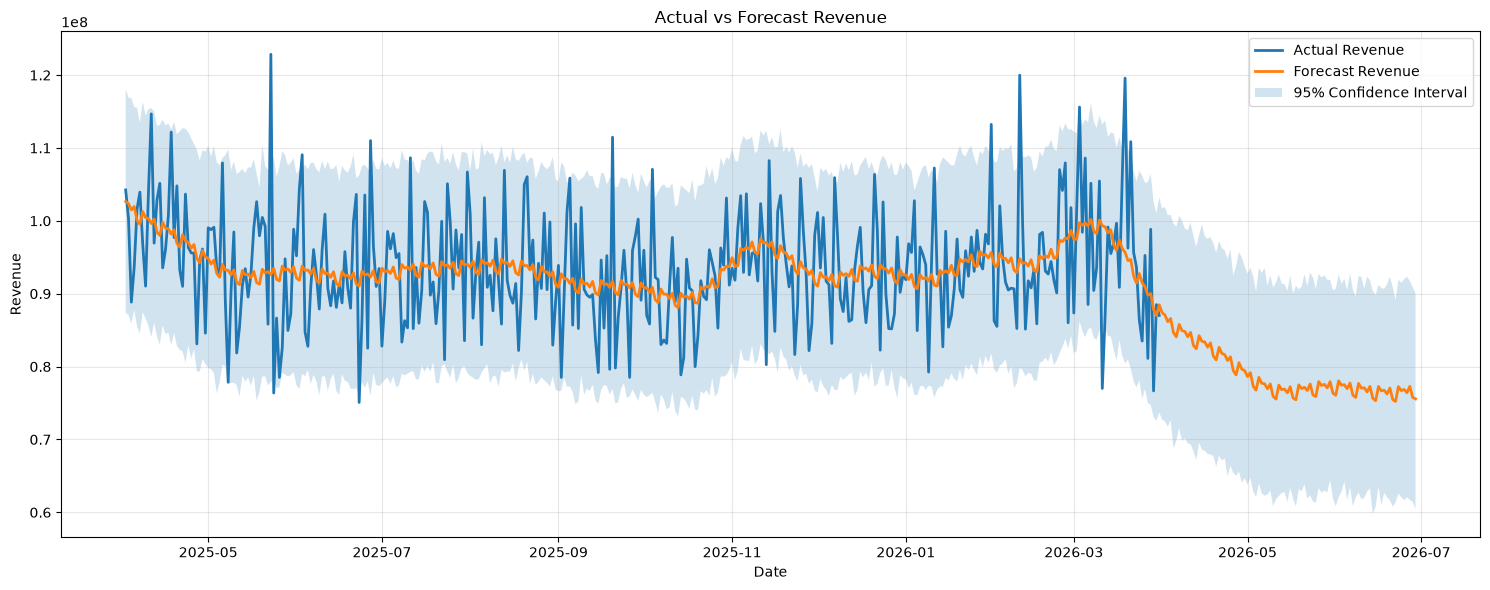


Next 90 Days Forecast
            ds          yhat    yhat_lower    yhat_upper         trend
364 2026-04-01  8.740944e+07  7.273521e+07  1.017154e+08  8.573744e+07
365 2026-04-02  8.707340e+07  7.245770e+07  1.018961e+08  8.569419e+07
366 2026-04-03  8.615475e+07  7.176711e+07  1.007441e+08  8.565094e+07
367 2026-04-04  8.659532e+07  7.265547e+07  1.008350e+08  8.560769e+07
368 2026-04-05  8.466154e+07  6.872925e+07  9.962217e+07  8.556444e+07
..         ...           ...           ...           ...           ...
449 2026-06-25  7.686065e+07  6.167672e+07  9.197936e+07  8.206115e+07
450 2026-06-26  7.640873e+07  6.206759e+07  9.234007e+07  8.201790e+07
451 2026-06-27  7.728741e+07  6.171328e+07  9.175324e+07  8.197465e+07
452 2026-06-28  7.576386e+07  6.143739e+07  9.089799e+07  8.193140e+07
453 2026-06-29  7.556201e+07  6.044938e+07  9.009414e+07  8.188815e+07

[90 rows x 5 columns]

Next 90 days forecast saved successfully.


In [57]:
# ==========================================================
# 9. Plot Forecast
# ==========================================================

fig = model.plot(forecast)

ax = plt.gca()
ax.set_title("Daily Revenue Forecast (Next 90 Days)", fontsize=15)
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")

plt.tight_layout()
plt.show()

# ==========================================================
# 10. Forecast Components
# ==========================================================

fig2 = model.plot_components(forecast)

plt.tight_layout()
plt.show()

# ==========================================================
# 11. Actual vs Forecast Plot
# ==========================================================

plt.figure(figsize=(15,6))

# Actual Revenue
plt.plot(
    daily_sales['ds'],
    daily_sales['y'],
    label='Actual Revenue',
    linewidth=2
)

# Forecast Revenue
plt.plot(
    forecast_result['ds'],
    forecast_result['yhat'],
    label='Forecast Revenue',
    linewidth=2
)

# Confidence Interval
plt.fill_between(
    forecast_result['ds'],
    forecast_result['yhat_lower'],
    forecast_result['yhat_upper'],
    alpha=0.2,
    label='95% Confidence Interval'
)

plt.title("Actual vs Forecast Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================================
# 12. Show Future 90-Day Forecast Only
# ==========================================================

future_forecast = forecast_result[
    forecast_result['ds'] > daily_sales['ds'].max()
]

print("\nNext 90 Days Forecast")
print(future_forecast)

future_forecast.to_csv(
    r"D:\Data Analyst\EXCEL\supplychain\cleaned\forcast\next_90_days_forecast.csv",
    index=False
)

print("\nNext 90 days forecast saved successfully.")

In [58]:
daily_revenue = (
    df.groupby('order_date')['net_amount']
      .sum()
      .reset_index()
)

daily_revenue.columns = ['ds', 'y']
daily_revenue.head()

,ds,y
0,2025-04-02,1.042411e+08
1,2025-04-03,1.003444e+08
2,2025-04-04,8.884024e+07
3,2025-04-05,9.363554e+07
4,2025-04-06,1.016375e+08


In [59]:
# Calculate Q1 and Q3
Q1 = daily_revenue['y'].quantile(0.25)
Q3 = daily_revenue['y'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define lower and upper bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Find outliers
outliers = daily_revenue[
    (daily_revenue['y'] < lower) |
    (daily_revenue['y'] > upper)
]

print(outliers)

            ds             y
9   2025-04-11  1.146696e+08
51  2025-05-23  1.228472e+08
314 2026-02-10  1.199839e+08
335 2026-03-03  1.156094e+08
351 2026-03-19  1.195764e+08


In [60]:
print("Number of outliers:", len(outliers))

Number of outliers: 5


In [61]:
percentage = len(outliers) / len(daily_revenue) * 100
print(f"Outlier Percentage: {percentage:.2f}%")

Outlier Percentage: 1.37%


In [72]:
imp=df[['order_line_id','order_date','customer_id','category','brand','quantity','unit_price','net_amount','product_name']]

In [ ]:
imp[imp['order_date']==pd.Timestamp('11-04-2025')].sort_values('net_amount',ascending=False)



,order_line_id,order_date,customer_id,category,brand,quantity,unit_price,net_amount,product_name
452323,OL00452324,2025-11-04,CUST019528,Jewellery,Rolex,4,1150000,4732066.27,Submariner Date Automatic
540116,OL00540117,2025-11-04,CUST003675,Jewellery,Rolex,3,1150000,3538366.27,Submariner Date Automatic
436809,OL00436810,2025-11-04,CUST065391,Jewellery,Rolex,3,1150000,3280001.64,Submariner Date Automatic
661212,OL00661213,2025-11-04,CUST046139,Jewellery,Omega,3,580000,1656526.27,Speedmaster Moonwatch Professional
645971,OL00645972,2025-11-04,CUST063759,Office Supplies,Sony,3,499999,1494943.28,Sony VPL-FHZ60 6000L Laser
...,...,...,...,...,...,...,...,...,...
326517,OL00326518,2025-11-04,CUST040336,Groceries,Britannia,2,50,144.10,Britannia NutriChoice Oatmeal Cookies
669140,OL00669141,2025-11-04,CUST032615,Groceries,Lay's,1,99,142.89,Lay's Classic Salted 200g
88599,OL00088600,2025-11-04,CUST090135,Groceries,Britannia,1,55,139.44,Multigrain Bread Loaf 400g
287161,OL00287162,2025-11-04,CUST039929,Groceries,24 Mantra Organic,3,29,128.95,Ginger 200g


In [74]:
imp[imp['order_date']==pd.Timestamp('2025-05-23')].sort_values('net_amount',ascending=False)

,order_line_id,order_date,customer_id,category,brand,quantity,unit_price,net_amount,product_name
527802,OL00527803,2025-05-23,CUST014847,Jewellery,Rolex,4,1150000,4500226.27,Submariner Date Automatic
270499,OL00270500,2025-05-23,CUST090705,Jewellery,Rolex,4,1150000,4454686.27,Submariner Date Automatic
63692,OL00063693,2025-05-23,CUST017659,Jewellery,Omega,5,580000,3007096.64,Speedmaster Moonwatch Professional
502666,OL00502667,2025-05-23,CUST066334,Jewellery,Omega,5,580000,2926146.27,Speedmaster Moonwatch Professional
674245,OL00674246,2025-05-23,CUST051974,Jewellery,Omega,4,580000,2245975.79,Speedmaster Moonwatch Professional
...,...,...,...,...,...,...,...,...,...
502701,OL00502702,2025-05-23,CUST077736,Groceries,Tata Salt,1,30,117.21,Table Salt Iodized 1kg
415276,OL00415277,2025-05-23,CUST056868,Groceries,ITC Bingo,1,30,116.00,Bingo Mad Angles Achaari Masti
141283,OL00141284,2025-05-23,CUST032710,Groceries,ITC Bingo,2,30,107.48,Bingo Mad Angles Achaari Masti
185770,OL00185771,2025-05-23,CUST058379,Groceries,Tata Salt,2,30,107.05,Table Salt Iodized 1kg


In [75]:
imp[imp['order_date']==pd.Timestamp('2026-02-10')].sort_values('net_amount',ascending=False)

,order_line_id,order_date,customer_id,category,brand,quantity,unit_price,net_amount,product_name
762908,OL00762909,2026-02-10,CUST081309,Jewellery,Rolex,5,1150000,5849115.79,Submariner Date Automatic
116569,OL00116570,2026-02-10,CUST023781,Jewellery,Rolex,5,1150000,5833421.27,Submariner Date Automatic
176951,OL00176952,2026-02-10,CUST009812,Jewellery,Rolex,5,1150000,5715586.64,Submariner Date Automatic
442138,OL00442139,2026-02-10,CUST063593,Jewellery,Omega,5,580000,2945866.27,Speedmaster Moonwatch Professional
72580,OL00072581,2026-02-10,CUST045367,Jewellery,Omega,5,580000,2772776.64,Speedmaster Moonwatch Professional
...,...,...,...,...,...,...,...,...,...
517209,OL00517210,2026-02-10,CUST029271,Beauty,Himalaya,1,99,148.21,Face Wash Neem
194847,OL00194848,2026-02-10,CUST051474,Groceries,Modern Bread,1,59,142.71,Pita Bread 6 Pieces
470838,OL00470839,2026-02-10,CUST035922,Groceries,Fresho,1,59,102.44,Baby Spinach 200g
21389,OL00021390,2026-02-10,CUST076984,Groceries,Kurkure,2,20,85.51,Kurkure Masala Munch 100g


In [76]:
imp[imp['order_date']==pd.Timestamp('2026-03-03')].sort_values('net_amount',ascending=False)

,order_line_id,order_date,customer_id,category,brand,quantity,unit_price,net_amount,product_name
151245,OL00151246,2026-03-03,CUST073144,Jewellery,Rolex,4,1150000,4816706.27,Submariner Date Automatic
634214,OL00634215,2026-03-03,CUST035495,Jewellery,Rolex,4,1150000,4571566.64,Submariner Date Automatic
380524,OL00380525,2026-03-03,CUST048817,Jewellery,Rolex,4,1150000,4395386.64,Submariner Date Automatic
325428,OL00325429,2026-03-03,CUST000807,Jewellery,Rolex,2,1150000,2414816.27,Submariner Date Automatic
582151,OL00582152,2026-03-03,CUST051526,Electronics,Nikon,5,349990,1779260.80,Z8 Mirrorless
...,...,...,...,...,...,...,...,...,...
463958,OL00463959,2026-03-03,CUST001985,Groceries,Vedaka,1,109,152.89,Chana Dal 1kg
606259,OL00606260,2026-03-03,CUST023995,Groceries,Fresho,1,89,130.96,Pineapple 1 Kg
138995,OL00138996,2026-03-03,CUST019358,Groceries,Yoga Bar,1,40,124.92,Yoga Bar Oats & Berries Bar
685252,OL00685253,2026-03-03,CUST084079,Groceries,24 Mantra Organic,2,29,105.70,Ginger 200g


In [77]:
imp[imp['order_date']==pd.Timestamp('2026-03-19')].sort_values('net_amount',ascending=False)

,order_line_id,order_date,customer_id,category,brand,quantity,unit_price,net_amount,product_name
591349,OL00591350,2026-03-19,CUST030767,Jewellery,Rolex,5,1150000,5829971.27,Submariner Date Automatic
426053,OL00426054,2026-03-19,CUST005300,Jewellery,Rolex,4,1150000,4824526.27,Submariner Date Automatic
338888,OL00338889,2026-03-19,CUST020997,Jewellery,Rolex,3,1150000,3601846.27,Submariner Date Automatic
596869,OL00596870,2026-03-19,CUST080191,Jewellery,Omega,5,580000,2958046.27,Speedmaster Moonwatch Professional
712743,OL00712744,2026-03-19,CUST036543,Jewellery,Omega,5,580000,2803935.79,Speedmaster Moonwatch Professional
...,...,...,...,...,...,...,...,...,...
415630,OL00415631,2026-03-19,CUST035751,Groceries,Nature's Basket,1,79,128.11,Zucchini Green 500g
101677,OL00101678,2026-03-19,CUST006262,Groceries,24 Mantra Organic,2,29,106.71,Ginger 200g
297244,OL00297245,2026-03-19,CUST075515,Groceries,Britannia,1,55,100.98,Multigrain Bread Loaf 400g
327344,OL00327345,2026-03-19,CUST049086,Groceries,Yoga Bar,1,40,87.38,Yoga Bar Oats & Berries Bar
